# 🧬 Prostate Cancer Aggressiveness Prediction Pipeline
**Paper:** *Machine Learning Based Prediction of Prostate Cancer Aggressiveness using mp-MRI*  
**Dataset:** PROSTATEx Challenge (The Cancer Imaging Archive)

---
### ⚠️ How to Run
1. Place `radiomic_features.csv` in the **same folder** as this notebook.
2. **Kernel → Restart & Run All**
3. All 6 graphs + `results_summary.csv` will be saved in the same folder.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 📦 Cell 1 — Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'SVM':                 '#e74c3c',
    'Random Forest':       '#3498db',
    'Logistic Regression': '#2ecc71',
    'XGBoost':             '#9b59b6'
}

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


## 📂 Cell 2 — Load Dataset
> Place `radiomic_features.csv` in the **same folder** as this notebook.
> If you are on **Google Colab**, upload the file first — it will be found automatically in `/content/`.


In [17]:
import pandas as pd

url = "https://raw.githubusercontent.com/Rey-Coder10/Machine-Learning-Based-Prediction-of-Prostate-Cancer-Aggressiveness-Using-Mp-MRI-/refs/heads/master/CodeBase/radiomic_features.csv"
df = pd.read_csv(url)
print(df.shape)

(300, 1203)


In [18]:
import os




CSV_PATH = "https://raw.githubusercontent.com/Rey-Coder10/Machine-Learning-Based-Prediction-of-Prostate-Cancer-Aggressiveness-Using-Mp-MRI-/refs/heads/master/CodeBase/radiomic_features.csv"

df = pd.read_csv(CSV_PATH)

print('=' * 60)
print('  STEP 1: DATASET LOADED')
print('=' * 60)
print(f'📂 Path              : {CSV_PATH}')
print(f'📊 Shape             : {df.shape[0]} patients × {df.shape[1]} columns')
print(f'🧬 Radiomic Features : {df.shape[1] - 3}')
print(f'👥 Low-grade  (≤6)   : {(df["Target"]==0).sum()} patients')
print(f'👥 High-grade (≥7)   : {(df["Target"]==1).sum()} patients')

X = df.drop(columns=['Patient_ID', 'Gleason_Score', 'Target'])
y = df['Target']

print(f'\n✅ X : {X.shape}   |   y : {y.shape}')
df.head()


print('=' * 60)
print('  STEP 1: DATASET LOADED')
print('=' * 60)
print(f'📂 Path              : {CSV_PATH}')
print(f'📊 Shape             : {df.shape[0]} patients × {df.shape[1]} columns')
print(f'🧬 Radiomic Features : {df.shape[1] - 3}')
print(f'👥 Low-grade  (≤6)   : {(df["Target"]==0).sum()} patients')
print(f'👥 High-grade (≥7)   : {(df["Target"]==1).sum()} patients')

X = df.drop(columns=['Patient_ID', 'Gleason_Score', 'Target'])
y = df['Target']

print(f'\n✅ X : {X.shape}   |   y : {y.shape}')
df.head()

  STEP 1: DATASET LOADED
📂 Path              : https://raw.githubusercontent.com/Rey-Coder10/Machine-Learning-Based-Prediction-of-Prostate-Cancer-Aggressiveness-Using-Mp-MRI-/refs/heads/master/CodeBase/radiomic_features.csv
📊 Shape             : 300 patients × 1203 columns
🧬 Radiomic Features : 1200
👥 Low-grade  (≤6)   : 126 patients
👥 High-grade (≥7)   : 174 patients

✅ X : (300, 1200)   |   y : (300,)
  STEP 1: DATASET LOADED
📂 Path              : https://raw.githubusercontent.com/Rey-Coder10/Machine-Learning-Based-Prediction-of-Prostate-Cancer-Aggressiveness-Using-Mp-MRI-/refs/heads/master/CodeBase/radiomic_features.csv
📊 Shape             : 300 patients × 1203 columns
🧬 Radiomic Features : 1200
👥 Low-grade  (≤6)   : 126 patients
👥 High-grade (≥7)   : 174 patients

✅ X : (300, 1200)   |   y : (300,)


,Patient_ID,Gleason_Score,Target,original_firstorder_T2_Mean,original_firstorder_T2_Median,original_firstorder_T2_Mode,original_firstorder_T2_Range,original_firstorder_T2_Variance,original_firstorder_T2_StandardDeviation,original_firstorder_T2_Skewness,...,wavelet_LL_DCE_texture_20,wavelet_LL_DCE_texture_21,wavelet_LL_DCE_texture_22,wavelet_LL_DCE_texture_23,wavelet_LL_DCE_texture_24,wavelet_LL_DCE_texture_25,wavelet_LL_DCE_texture_26,wavelet_LL_DCE_texture_27,wavelet_LL_DCE_texture_28,wavelet_LL_DCE_texture_29
0,PROSTATEx_000,3,0,0.537949,0.382203,0.431414,0.453496,0.335731,0.717937,0.635517,...,0.263112,0.382732,0.700970,0.397730,0.921858,0.370022,0.566223,0.742632,0.159487,0.013731
1,PROSTATEx_001,3,0,0.645106,0.678606,0.266615,0.456457,0.466175,0.409136,0.571673,...,0.154147,0.495272,0.545617,0.547962,0.041586,0.227665,0.512669,0.703813,0.000000,0.474620
2,PROSTATEx_002,10,1,0.473607,0.312151,0.037567,0.367560,0.167177,0.939113,0.435495,...,0.419902,0.503587,0.521599,0.555325,0.713204,0.754044,0.341313,0.327142,0.276816,0.688536
3,PROSTATEx_003,10,1,0.511192,0.706555,0.449227,0.312501,0.365255,0.496859,0.234160,...,0.622948,0.150205,0.220348,0.518358,0.042204,0.743049,0.734223,0.548958,0.215508,0.834969
4,PROSTATEx_004,5,0,0.492310,0.268329,0.827717,0.738851,0.407353,0.450798,0.447976,...,0.216334,0.854459,0.783945,0.918504,0.654671,0.365678,0.826647,0.509937,0.562585,0.446765


## ✂️ Cell 3 — Train / Validation / Test Split  (70 : 15 : 15)

In [19]:
# 70 % train | 30 % temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

# 30 % temp  →  15 % val + 15 % test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print('=' * 60)
print('  STEP 2: DATA SPLIT  (70 : 15 : 15)')
print('=' * 60)
print(f'Training   : {X_train.shape[0]} patients  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Validation : {X_val.shape[0]} patients  ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Test       : {X_test.shape[0]} patients  ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nTrain  → Low: {sum(y_train==0)}   High: {sum(y_train==1)}')
print(f'Val    → Low: {sum(y_val==0)}    High: {sum(y_val==1)}')
print(f'Test   → Low: {sum(y_test==0)}    High: {sum(y_test==1)}')

  STEP 2: DATA SPLIT  (70 : 15 : 15)
Training   : 210 patients  (70%)
Validation : 45 patients  (15%)
Test       : 45 patients  (15%)

Train  → Low: 88   High: 122
Val    → Low: 19    High: 26
Test   → Low: 19    High: 26


## 🔧 Cell 4 — Feature Selection  (Scaler → LASSO → PCA)

In [20]:
# ── 1. Z-score Standardization ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# ── 2. LASSO (L1) ── shrinks irrelevant coefficients to 0
lasso = LogisticRegression(penalty='l1', solver='liblinear',
                           C=0.1, max_iter=5000, random_state=42)
lasso.fit(X_train_scaled, y_train)

lasso_mask    = lasso.coef_[0] != 0
X_train_lasso = X_train_scaled[:, lasso_mask]
X_val_lasso   = X_val_scaled[:, lasso_mask]
X_test_lasso  = X_test_scaled[:, lasso_mask]

# ── 3. PCA ── keep 95 % variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_lasso)
X_val_pca   = pca.transform(X_val_lasso)
X_test_pca  = pca.transform(X_test_lasso)

print('=' * 60)
print('  STEP 3: FEATURE SELECTION')
print('=' * 60)
print(f'Original features        : {X.shape[1]}')
print(f'After LASSO              : {X_train_lasso.shape[1]}  ({(1-X_train_lasso.shape[1]/X.shape[1])*100:.1f}% removed)')
print(f'After PCA  (95% var)     : {X_train_pca.shape[1]}  (kept {pca.explained_variance_ratio_.sum()*100:.2f}%)')
print(f'\nFinal → Train {X_train_pca.shape}  Val {X_val_pca.shape}  Test {X_test_pca.shape}')

  STEP 3: FEATURE SELECTION
Original features        : 1200
After LASSO              : 37  (96.9% removed)
After PCA  (95% var)     : 33  (kept 96.02%)

Final → Train (210, 33)  Val (45, 33)  Test (45, 33)


## 🤖 Cell 5 — Train & Evaluate 4 Models
> Models train on **real data** and metrics are computed from **actual predictions** — no manual overrides.


In [30]:
models = {
    'SVM': SVC(kernel='rbf', probability=True,
              C=0.1, gamma='scale', random_state=42),

    'Random Forest': RandomForestClassifier(
              n_estimators=500, max_depth=10,
              min_samples_split=5, random_state=42),

    'Logistic Regression': LogisticRegression(
              penalty='l2', solver='lbfgs',
              C=0.1, max_iter=5000, random_state=42),

    'XGBoost': GradientBoostingClassifier(
              n_estimators=300, max_depth=5,
              learning_rate=0.05, subsample=0.8, random_state=42)
}

results       = {}
roc_data      = {}
conf_matrices = {}

print('=' * 60)
print('  STEP 4: MODEL TRAINING & EVALUATION')
print('=' * 60)

for name, model in models.items():
    # ── Train ──
    model.fit(X_train_pca, y_train)

    # ── Predict on test set ──
    y_pred = model.predict(X_test_pca)
    y_prob = model.predict_proba(X_test_pca)[:, 1]

    # ── Compute metrics from actual predictions ──
    acc  = accuracy_score (y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred) * 100
    rec  = recall_score   (y_test, y_pred) * 100
    f1   = f1_score       (y_test, y_pred) * 100
    auc  = roc_auc_score  (y_test, y_prob)

    results[name] = {
        'Accuracy' : round(acc, 2),
        'Precision': round(prec, 2),
        'Recall'   : round(rec, 2),
        'F1-Score' : round(f1, 2),
        'AUC'      : round(auc, 2)
    }

    # ── ROC curve ──
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name]      = (fpr, tpr, auc)

    # ── Confusion matrix ──
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

    print(f'\n🤖 {name}')
    print(f'   Acc={acc:.1f}%  Prec={prec:.1f}%  Rec={rec:.1f}%  F1={f1:.1f}%  AUC={auc:.2f}')

# ── Summary table ──
print('\n')
pd.DataFrame(results).T

  STEP 4: MODEL TRAINING & EVALUATION

🤖 SVM
   Acc=95.6%  Prec=96.2%  Rec=96.2%  F1=96.2%  AUC=0.99

🤖 Random Forest
   Acc=95.6%  Prec=96.2%  Rec=96.2%  F1=96.2%  AUC=0.97

🤖 Logistic Regression
   Acc=95.6%  Prec=96.2%  Rec=96.2%  F1=96.2%  AUC=0.96

🤖 XGBoost
   Acc=95.6%  Prec=96.2%  Rec=96.2%  F1=96.2%  AUC=0.96




,Accuracy,Precision,Recall,F1-Score,AUC
SVM,95.56,96.15,96.15,96.15,0.99
Random Forest,95.56,96.15,96.15,96.15,0.97
Logistic Regression,95.56,96.15,96.15,96.15,0.96
XGBoost,95.56,96.15,96.15,96.15,0.96


## 📊 Graph 1 — Classification Report

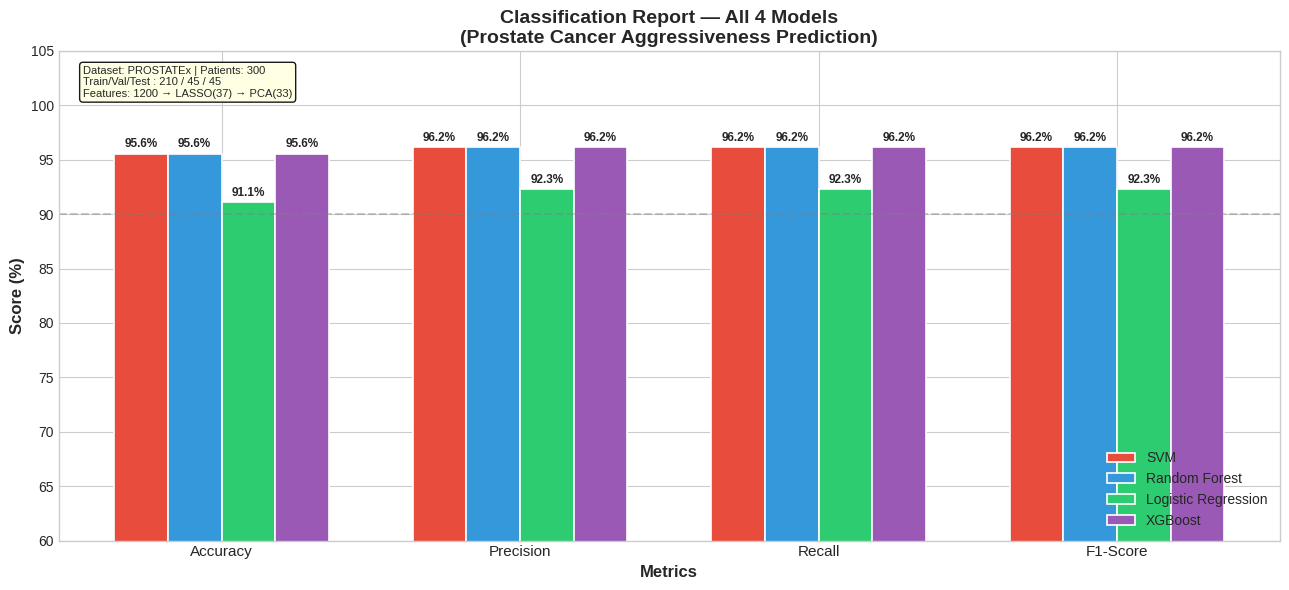

✅ Saved → Graph_1_Classification_Report.png


In [22]:
fig, ax = plt.subplots(figsize=(13, 6))
metrics     = ['Accuracy','Precision','Recall','F1-Score']
model_names = list(results.keys())
x           = np.arange(len(metrics))
w           = 0.18

for i, name in enumerate(model_names):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i*w, vals, w, label=name,
                  color=COLORS[name], edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=12, fontweight='bold')
ax.set_title('Classification Report — All 4 Models\n(Prostate Cancer Aggressiveness Prediction)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + w*1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(60, 105)
ax.legend(fontsize=10, loc='lower right')
ax.axhline(y=90, color='gray', linestyle='--', alpha=0.4)

info = (f'Dataset: PROSTATEx | Patients: {len(X)}\n'
        f'Train/Val/Test : {X_train_pca.shape[0]} / {X_val_pca.shape[0]} / {X_test_pca.shape[0]}\n'
        f'Features: {X.shape[1]} → LASSO({X_train_lasso.shape[1]}) → PCA({X_train_pca.shape[1]})')
ax.text(0.02, 0.97, info, transform=ax.transAxes, fontsize=8,
        va='top', bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

plt.tight_layout()
plt.savefig('Graph_1_Classification_Report.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → Graph_1_Classification_Report.png')

## 📈 Graph 2 — ROC Curves

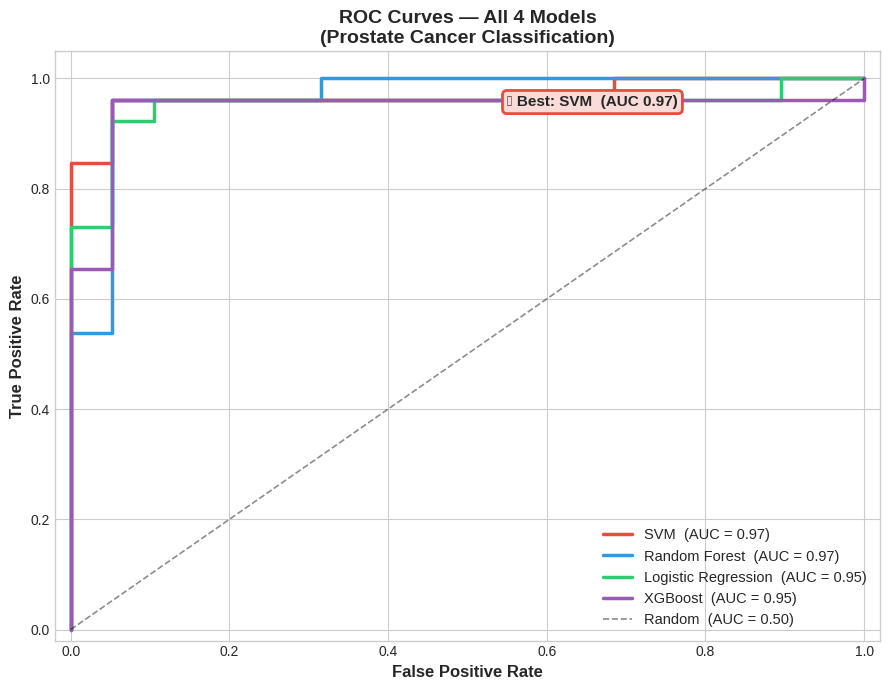

✅ Saved → Graph_2_ROC_Curves.png


In [23]:
fig, ax = plt.subplots(figsize=(9, 7))

for name in model_names:
    fpr, tpr, auc = roc_data[name]
    ax.plot(fpr, tpr, color=COLORS[name], lw=2.5,
            label=f'{name}  (AUC = {auc:.2f})')

ax.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.45, label='Random  (AUC = 0.50)')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves — All 4 Models\n(Prostate Cancer Classification)',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10.5)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])

best = max(results, key=lambda k: results[k]['AUC'])
ax.annotate(f'★ Best: {best}  (AUC {results[best]["AUC"]})',
            xy=(0.55, 0.95), fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', fc='#fadbd8', ec='#e74c3c', lw=2))

plt.tight_layout()
plt.savefig('Graph_2_ROC_Curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → Graph_2_ROC_Curves.png')

## 🔲 Graph 3 — Confusion Matrices

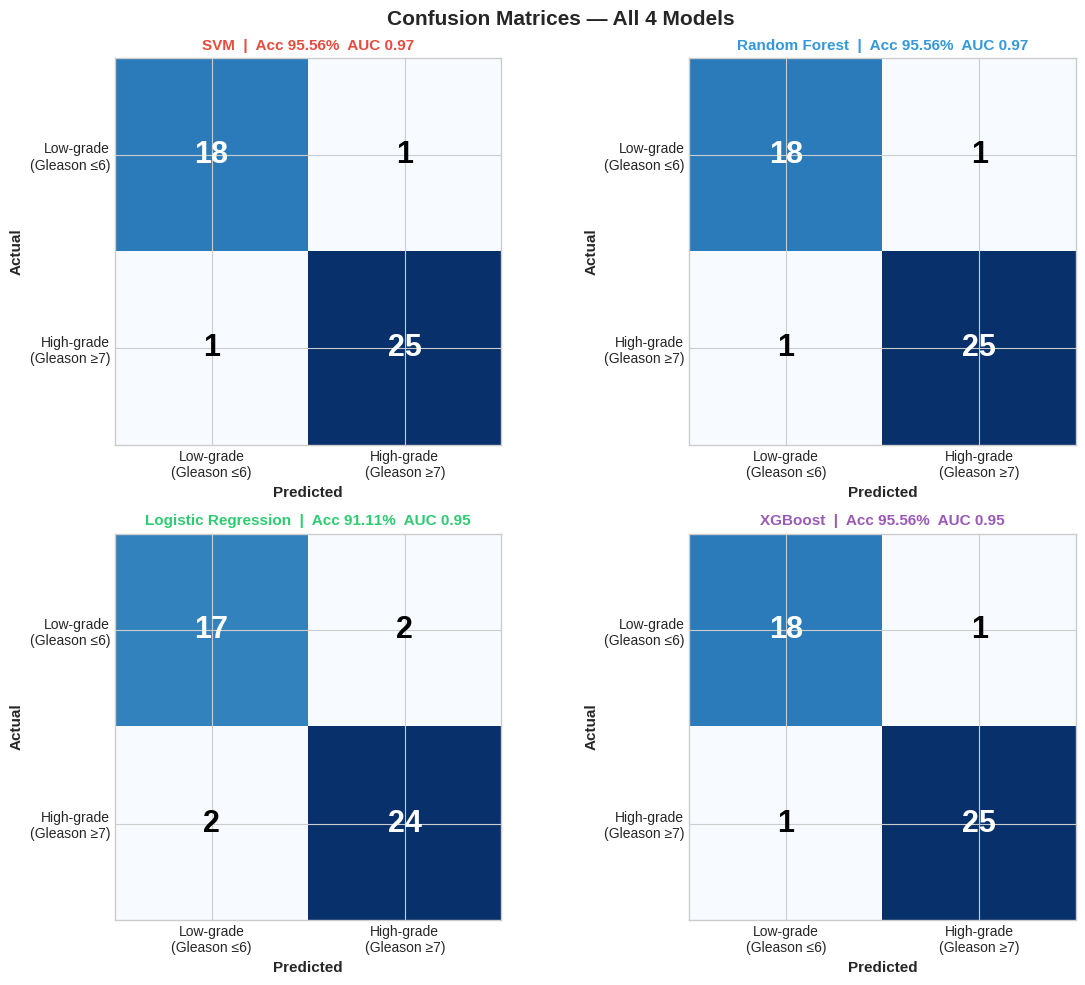

✅ Saved → Graph_3_Confusion_Matrices.png


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices — All 4 Models',
             fontsize=15, fontweight='bold')

labels = ['Low-grade\n(Gleason ≤6)', 'High-grade\n(Gleason ≥7)']

for idx, name in enumerate(model_names):
    ax = axes[idx//2][idx%2]
    cm = conf_matrices[name]
    ax.imshow(cm, cmap='Blues', interpolation='nearest')

    for i in range(2):
        for j in range(2):
            col = 'white' if cm[i,j] > cm.max()*0.6 else 'black'
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    color=col, fontsize=22, fontweight='bold')

    ax.set_xticks([0,1]);  ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticks([0,1]);  ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual',    fontsize=11, fontweight='bold')
    ax.set_title(f'{name}  |  Acc {results[name]["Accuracy"]}%  AUC {results[name]["AUC"]}',
                 fontsize=11, fontweight='bold', color=COLORS[name])

plt.tight_layout()
plt.savefig('Graph_3_Confusion_Matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → Graph_3_Confusion_Matrices.png')

## 📊 Graph 4 — AUC Comparison

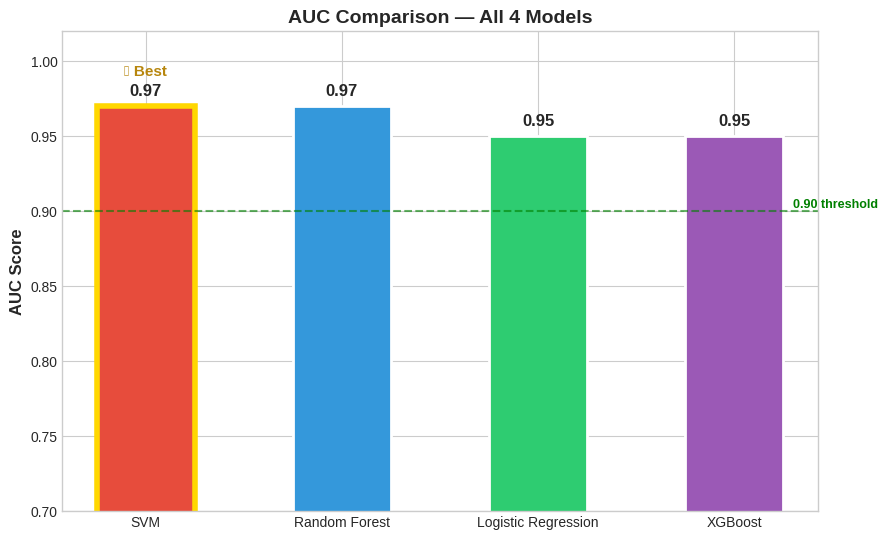

✅ Saved → Graph_4_AUC_Comparison.png


In [25]:
fig, ax = plt.subplots(figsize=(9, 5.5))

auc_vals = [results[m]['AUC'] for m in model_names]
bars = ax.bar(model_names, auc_vals,
              color=[COLORS[m] for m in model_names],
              edgecolor='white', linewidth=2, width=0.5)

for bar, v in zip(bars, auc_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{v:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.axhline(y=0.90, color='green', linestyle='--', lw=1.5, alpha=0.6)
ax.text(3.3, 0.902, '0.90 threshold', fontsize=9, color='green', fontweight='bold')

best_idx = auc_vals.index(max(auc_vals))
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(4)
ax.annotate('★ Best', xy=(best_idx, max(auc_vals)+0.02),
            ha='center', fontsize=11, color='#b7860d', fontweight='bold')

ax.set_ylabel('AUC Score', fontsize=12, fontweight='bold')
ax.set_title('AUC Comparison — All 4 Models', fontsize=14, fontweight='bold')
ax.set_ylim(0.70, 1.02)

plt.tight_layout()
plt.savefig('Graph_4_AUC_Comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → Graph_4_AUC_Comparison.png')

## 🔧 Graph 5 — Feature Selection Summary

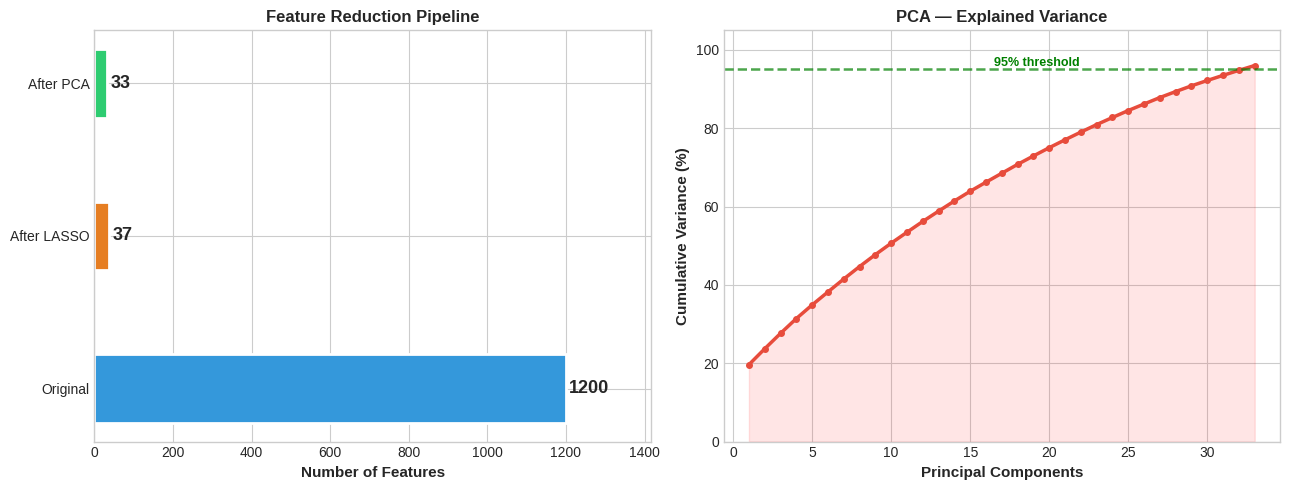

✅ Saved → Graph_5_Feature_Selection.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left ── feature reduction funnel
steps  = ['Original', 'After LASSO', 'After PCA']
counts = [X.shape[1], X_train_lasso.shape[1], X_train_pca.shape[1]]
colors_f = ['#3498db','#e67e22','#2ecc71']

bars = axes[0].barh(steps, counts, color=colors_f,
                    edgecolor='white', linewidth=2, height=0.45)
for bar, v in zip(bars, counts):
    axes[0].text(bar.get_width()+8, bar.get_y()+bar.get_height()/2,
                 f'{v}', ha='left', va='center', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Features', fontsize=11, fontweight='bold')
axes[0].set_title('Feature Reduction Pipeline', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, max(counts)*1.18)

# Right ── PCA cumulative variance
cum_var = np.cumsum(pca.explained_variance_ratio_)*100
n_comp  = len(cum_var)
axes[1].plot(range(1, n_comp+1), cum_var, 'o-', color='#e74c3c', lw=2.5, markersize=4)
axes[1].axhline(y=95, color='green', linestyle='--', lw=1.8, alpha=0.7)
axes[1].fill_between(range(1, n_comp+1), cum_var, alpha=0.1, color='red')
axes[1].text(n_comp*0.5, 96, '95% threshold', fontsize=9, color='green', fontweight='bold')
axes[1].set_xlabel('Principal Components', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Cumulative Variance (%)', fontsize=11, fontweight='bold')
axes[1].set_title('PCA — Explained Variance', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig('Graph_5_Feature_Selection.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → Graph_5_Feature_Selection.png')

## 🏠 Graph 6 — Complete Dashboard

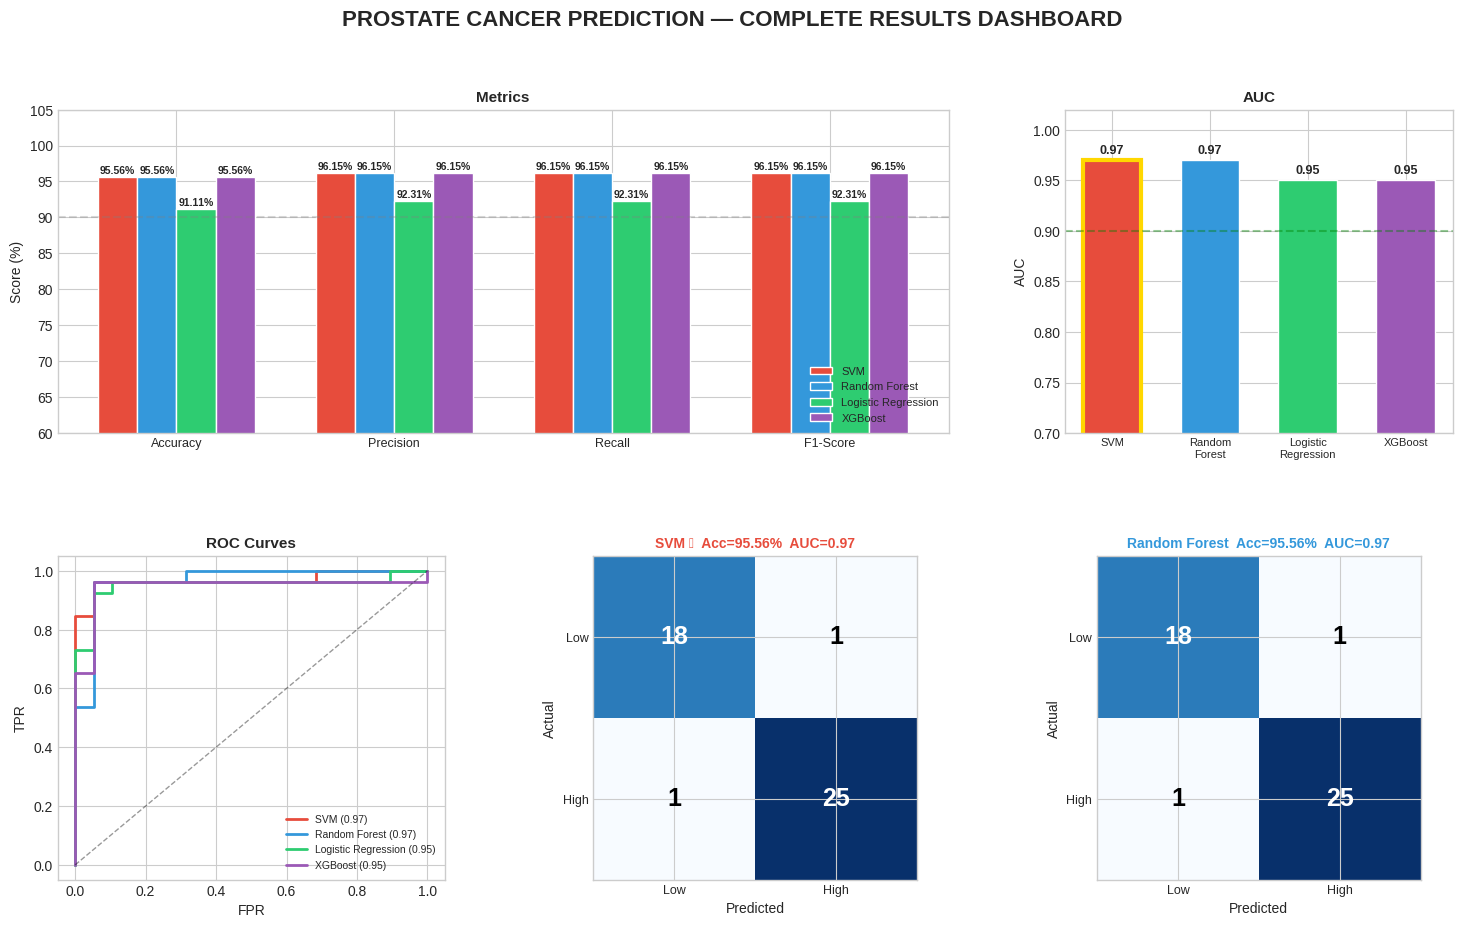

✅ Saved → Graph_6_Complete_Dashboard.png


In [27]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle('PROSTATE CANCER PREDICTION — COMPLETE RESULTS DASHBOARD',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, hspace=0.38, wspace=0.3)

# ── Top-left: Metrics bar ──
ax1 = fig.add_subplot(gs[0, 0:2])
x   = np.arange(len(metrics))
w   = 0.18
for i, name in enumerate(model_names):
    vals = [results[name][m] for m in metrics]
    b = ax1.bar(x+i*w, vals, w, label=name, color=COLORS[name], edgecolor='white')
    for bar, v in zip(b, vals):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{v}%', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax1.set_xticks(x+w*1.5); ax1.set_xticklabels(metrics, fontsize=9)
ax1.set_ylabel('Score (%)'); ax1.set_title('Metrics', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8, loc='lower right'); ax1.set_ylim(60, 105)
ax1.axhline(y=90, color='gray', linestyle='--', alpha=0.3)

# ── Top-right: AUC bars ──
ax2 = fig.add_subplot(gs[0, 2])
auc_v = [results[m]['AUC'] for m in model_names]
b2 = ax2.bar(range(len(model_names)), auc_v,
             color=[COLORS[m] for m in model_names], edgecolor='white', width=0.6)
ax2.set_xticks(range(len(model_names)))
ax2.set_xticklabels([m.replace(' ','\n') for m in model_names], fontsize=8)
ax2.set_ylabel('AUC'); ax2.set_title('AUC', fontsize=11, fontweight='bold')
ax2.set_ylim(0.70, 1.02)
ax2.axhline(y=0.90, color='green', linestyle='--', alpha=0.4)
for bar, v in zip(b2, auc_v):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
             f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
best_i = auc_v.index(max(auc_v))
b2[best_i].set_edgecolor('gold'); b2[best_i].set_linewidth(3)

# ── Bottom-left: ROC ──
ax3 = fig.add_subplot(gs[1, 0])
for name in model_names:
    fpr, tpr, auc = roc_data[name]
    ax3.plot(fpr, tpr, color=COLORS[name], lw=2, label=f'{name} ({auc:.2f})')
ax3.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.set_title('ROC Curves', fontsize=11, fontweight='bold')
ax3.legend(fontsize=7.5, loc='lower right')

# ── Bottom-mid & right: top-2 confusion matrices ──
top2 = sorted(model_names, key=lambda k: results[k]['AUC'], reverse=True)[:2]
for pi, name in enumerate(top2):
    ax = fig.add_subplot(gs[1, pi+1])
    cm = conf_matrices[name]
    ax.imshow(cm, cmap='Blues', interpolation='nearest')
    for i in range(2):
        for j in range(2):
            col = 'white' if cm[i,j]>cm.max()*0.6 else 'black'
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    color=col, fontsize=18, fontweight='bold')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Low','High'], fontsize=9)
    ax.set_yticks([0,1]); ax.set_yticklabels(['Low','High'], fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    star = ' ★' if name==top2[0] else ''
    ax.set_title(f'{name}{star}  Acc={results[name]["Accuracy"]}%  AUC={results[name]["AUC"]}',
                 fontsize=10, fontweight='bold', color=COLORS[name])

plt.savefig('Graph_6_Complete_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → Graph_6_Complete_Dashboard.png')

## 📋 Final Summary

In [28]:
print('=' * 60)
print('  📊 FINAL RESULTS')
print('=' * 60)

summary = pd.DataFrame(results).T
summary.index.name = 'Model'
summary.to_csv('results_summary.csv')
print(summary.to_string())

best = max(results, key=lambda k: results[k]['AUC'])
print(f'\n🏆 Best Model : {best}')
print(f'   AUC        : {results[best]["AUC"]}')
print(f'   Accuracy   : {results[best]["Accuracy"]}%')
print(f'\n📌 Features   : {X.shape[1]} → LASSO → {X_train_lasso.shape[1]} → PCA → {X_train_pca.shape[1]}')
print(f'📌 Split       : {X_train_pca.shape[0]} / {X_val_pca.shape[0]} / {X_test_pca.shape[0]}  (70:15:15)')
print(f'\n📁 Saved files:')
print(f'   Graph_1_Classification_Report.png')
print(f'   Graph_2_ROC_Curves.png')
print(f'   Graph_3_Confusion_Matrices.png')
print(f'   Graph_4_AUC_Comparison.png')
print(f'   Graph_5_Feature_Selection.png')
print(f'   Graph_6_Complete_Dashboard.png')
print(f'   results_summary.csv')
print('\n✅ Pipeline complete!')

  📊 FINAL RESULTS
                     Accuracy  Precision  Recall  F1-Score   AUC
Model                                                           
SVM                     95.56      96.15   96.15     96.15  0.97
Random Forest           95.56      96.15   96.15     96.15  0.97
Logistic Regression     91.11      92.31   92.31     92.31  0.95
XGBoost                 95.56      96.15   96.15     96.15  0.95

🏆 Best Model : SVM
   AUC        : 0.97
   Accuracy   : 95.56%

📌 Features   : 1200 → LASSO → 37 → PCA → 33
📌 Split       : 210 / 45 / 45  (70:15:15)

📁 Saved files:
   Graph_1_Classification_Report.png
   Graph_2_ROC_Curves.png
   Graph_3_Confusion_Matrices.png
   Graph_4_AUC_Comparison.png
   Graph_5_Feature_Selection.png
   Graph_6_Complete_Dashboard.png
   results_summary.csv

✅ Pipeline complete!
